# 09 — Integrated Noul 2011 Case Study
## การบูรณาการ Synoptic Maps, Vertical Structure และ Spatiotemporal Analysis

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 pressure-level EVENT + ERA5 850-hPa 6-hourly zonal wind  
**ช่วงเหตุการณ์:** 2–5 October 2011 เวลา 00 UTC สำหรับ pressure-level snapshots  
**บทก่อนหน้า:** Notebook 08 — Anomaly Concepts and Baseline Matching

Notebook นี้เป็นบทสรุปของหลักสูตรช่วง 00–08

```text
data structure
→ maps
→ pressure levels
→ wind vectors
→ synoptic dynamics
→ Hovmöller
→ climatology
→ anomaly concepts
→ integrated case study
```

คำถามหลักของบท:

> **โครงสร้างบรรยากาศเหนือ Southeast Asia เปลี่ยนแปลงอย่างไรในช่วง 2–5 October 2011 และหลักฐานจาก lower-, middle-, upper-troposphere และ spatiotemporal context สอดคล้องกันอย่างไร?**

ข้อจำกัดสำคัญ:

> EVENT dataset มีเพียง **00-UTC synoptic snapshots** 4 วัน ไม่ใช่ daily means และไม่ใช่ complete storm lifecycle

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. ตรวจและเชื่อมข้อมูลสองชุดที่มี temporal resolution ต่างกัน
2. สร้าง 850-hPa lower-tropospheric synoptic maps
3. สร้าง 500-hPa relative-vorticity maps
4. สร้าง 200-hPa divergence maps
5. เปรียบเทียบ vertical structure ที่ 850/500/200 hPa
6. วิเคราะห์ evolution ระหว่าง 2–5 October 2011
7. สร้าง event-window Hovmöller diagram จากข้อมูล 6-hourly
8. สร้าง Thailand-area mean $u_{850}$ time series
9. เชื่อม map snapshots กับ Hovmöller pattern
10. สร้าง regional diagnostic table สำหรับแต่ละ event day
11. สังเคราะห์หลักฐานแบบ Observation → Interpretation → Limitation
12. แยกสิ่งที่ข้อมูลสนับสนุนออกจากสิ่งที่ยังพิสูจน์ไม่ได้
13. อธิบายว่าทำไม October climatological anomaly ไม่ถูกคำนวณ
14. export figures, tables, derived NetCDF และ case-study metadata

# 1. Integrated Atmospheric Analysis

การวิเคราะห์เหตุการณ์หนึ่งไม่ควรพึ่ง field เดียว

framework ของ Notebook 09 คือ:

```text
Lower troposphere
850 hPa
→ temperature / RH / height / wind

Middle troposphere
500 hPa
→ height / relative vorticity / wind

Upper troposphere
200 hPa
→ divergence / wind

Spatiotemporal context
6-hourly u850
→ Hovmöller + regional time series
```

จากนั้นจึงสังเคราะห์เป็น atmospheric narrative

# 2. Vertical Synthesis

การพิจารณาหลายระดับมีเป้าหมายเพื่อถามว่า low-level circulation, mid-level rotational structure และ upper-level divergence มีความสัมพันธ์เชิงโครงสร้างกันอย่างไร

แต่ต้องระวัง:

> **การเห็น pattern ที่สอดคล้องกันหลายระดับ ยังไม่ใช่การพิสูจน์ causal mechanism โดยสมบูรณ์**

# 3. Relative Vorticity

$$
\zeta
=
\frac{\partial v}{\partial x}
-
\frac{\partial u}{\partial y}
$$

ใน Northern Hemisphere:

```text
ζ > 0
→ cyclonic relative rotation
```

แต่:

```text
positive vorticity
≠ rising motion directly
```

# 4. Horizontal Divergence

$$
D
=
\frac{\partial u}{\partial x}
+
\frac{\partial v}{\partial y}
$$

```text
D > 0
→ horizontal divergence

D < 0
→ horizontal convergence
```

แต่:

```text
upper-level divergence
≠ direct measurement of vertical velocity
```

# 5. Hovmöller Context

Time–Longitude Hovmöller ใช้:

$$
\overline{u}(\lambda,t)
=
\frac{
\sum_{\phi}
u(\lambda,\phi,t)\cos\phi
}{
\sum_{\phi}
\cos\phi
}
$$

ในบทนี้ใช้ latitude band 10–20°N เพื่อดูการเปลี่ยนแปลงของ zonal-flow pattern ก่อน ระหว่าง และหลังช่วง 2–5 October

# 6. สิ่งที่ Notebook นี้จะไม่ทำ

Notebook 09 จะไม่:

```text
สร้าง October climatological anomaly
เรียก 00-UTC snapshots ว่า daily means
ใช้ positive vorticity เป็นหลักฐานของ ascent โดยตรง
ใช้ upper-level divergence เป็น proof of severe convection
ตีความ u850 เป็น total wind speed
```

เพราะแต่ละข้อเกินสิ่งที่ข้อมูลรองรับ

# 7. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 8. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print(
    "Google Drive mounted:",
    DRIVE_ROOT,
)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 9. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

G0 = 9.80665

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 10. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "09"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

SPATIOTEMPORAL_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc"
)

MONTHLY_BASELINE_CANDIDATES = [
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc"
    ),
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_1981_2020_Asia_0.5deg.nc"
    ),
]

MONTHLY_BASELINE_FILE = next(
    (
        path
        for path in MONTHLY_BASELINE_CANDIDATES
        if path.exists()
    ),
    None,
)

for required_file in [
    EVENT_FILE,
    SPATIOTEMPORAL_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required teaching dataset not found: {required_file}"
        )

print("EVENT file:", EVENT_FILE)
print("SPATIOTEMPORAL file:", SPATIOTEMPORAL_FILE)
print("Monthly baseline:", MONTHLY_BASELINE_FILE)

EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc
SPATIOTEMPORAL file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_u850_6hourly_20110901_20111031_Asia_0.5deg.nc
Monthly baseline: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc


# 11. เปิด Datasets

In [5]:
# CELL 5 — Open datasets

event_ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

spatiotemporal_ds = xr.open_dataset(
    SPATIOTEMPORAL_FILE,
    decode_times=True,
)

monthly_ds = (
    xr.open_dataset(
        MONTHLY_BASELINE_FILE,
        decode_times=True,
    )
    if MONTHLY_BASELINE_FILE is not None
    else None
)

print("EVENT")
print(event_ds)

print()
print("SPATIOTEMPORAL")
print(spatiotemporal_ds)

if monthly_ds is not None:
    print()
    print("MONTHLY BASELINE")
    print(monthly_ds)

EVENT
<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) float32 2MB ...
Attributes: (12/17)
    Conventions:        

# 12. Dataset Audit

In [6]:
# CELL 6 — Dataset audit

event_times = pd.DatetimeIndex(
    pd.to_datetime(
        event_ds["time"].values
    )
)

spatiotemporal_times = pd.DatetimeIndex(
    pd.to_datetime(
        spatiotemporal_ds["time"].values
    )
)

spatiotemporal_step_hours = float(
    (
        pd.Series(
            spatiotemporal_times
        )
        .diff()
        .dropna()
        .dt.total_seconds()
        / 3600.0
    ).median()
)

audit_rows = [
    {
        "dataset": "EVENT",
        "time_start": str(event_times.min()),
        "time_end": str(event_times.max()),
        "n_time": int(event_ds.sizes["time"]),
        "temporal_semantics": (
            "Four daily 00-UTC synoptic snapshots"
        ),
        "pressure_levels": str(
            event_ds["level"].values.tolist()
        ),
        "variables": ",".join(
            event_ds.data_vars
        ),
    },
    {
        "dataset": "SPATIOTEMPORAL",
        "time_start": str(spatiotemporal_times.min()),
        "time_end": str(spatiotemporal_times.max()),
        "n_time": int(spatiotemporal_ds.sizes["time"]),
        "temporal_semantics": (
            f"{spatiotemporal_step_hours:g}-hourly u850"
        ),
        "pressure_levels": (
            "850 hPa by source/preparation metadata"
        ),
        "variables": ",".join(
            spatiotemporal_ds.data_vars
        ),
    },
]

DATASET_AUDIT = pd.DataFrame(
    audit_rows
)

display(
    DATASET_AUDIT
)

if not np.isclose(
    spatiotemporal_step_hours,
    6.0,
):
    print(
        "WARNING: expected 6-hourly spatiotemporal data."
    )

,dataset,time_start,time_end,n_time,temporal_semantics,pressure_levels,variables
0,EVENT,2011-10-02 00:00:00,2011-10-05 00:00:00,4,Four daily 00-UTC synoptic snapshots,"[200, 250, 300, 500, 700, 850, 925, 1000]","d,z,r,q,t,u,v,vo"
1,SPATIOTEMPORAL,2011-09-01 00:00:00,2011-10-31 18:00:00,244,6-hourly u850,850 hPa by source/preparation metadata,u


# 13. October Baseline Audit

In [7]:
# CELL 7 — Confirm October climatology is unavailable

if monthly_ds is not None:
    monthly_months = sorted(
        np.unique(
            pd.DatetimeIndex(
                pd.to_datetime(
                    monthly_ds["time"].values
                )
            ).month
        ).tolist()
    )
else:
    monthly_months = []

OCTOBER_CLIMATOLOGY_AVAILABLE = (
    10 in monthly_months
)

OCTOBER_BASELINE_AUDIT = pd.DataFrame(
    [
        {
            "baseline_archive_available": (
                monthly_ds is not None
            ),
            "months_available": str(
                monthly_months
            ),
            "October_climatology_available": (
                OCTOBER_CLIMATOLOGY_AVAILABLE
            ),
            "policy": (
                "Do not compute October climatological anomaly"
                if not OCTOBER_CLIMATOLOGY_AVAILABLE
                else "October baseline available"
            ),
        }
    ]
)

display(
    OCTOBER_BASELINE_AUDIT
)

if OCTOBER_CLIMATOLOGY_AVAILABLE:
    print(
        "NOTE: this course version contains an October baseline."
    )
else:
    print(
        "Confirmed: no October climatology will be used."
    )

,baseline_archive_available,months_available,October_climatology_available,policy
0,True,"[1, 7]",False,Do not compute October climatological anomaly


Confirmed: no October climatology will be used.


# 14. Analysis Domains and Settings

In [8]:
# CELL 8 — Analysis settings

SE_ASIA_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

THAILAND_BOX = {
    "lon_min": 97.0,
    "lon_max": 106.0,
    "lat_min": 5.0,
    "lat_max": 21.0,
}

HOV_LAT_BAND = {
    "lat_min": 10.0,
    "lat_max": 20.0,
}

EVENT_WINDOW_START = pd.Timestamp(
    "2011-09-25 00:00:00"
)

EVENT_WINDOW_END = pd.Timestamp(
    "2011-10-10 18:00:00"
)

VECTOR_SKIP = 4

print(
    "EVENT dates:",
    event_times.tolist(),
)

EVENT dates: [Timestamp('2011-10-02 00:00:00'), Timestamp('2011-10-03 00:00:00'), Timestamp('2011-10-04 00:00:00'), Timestamp('2011-10-05 00:00:00')]


# 15. Helper Functions

In [9]:
# CELL 9 — Helpers

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def subset_domain(
    data_array,
    domain,
):
    subset = data_array.sel(
        latitude=coordinate_slice(
            data_array["latitude"],
            domain["lat_min"],
            domain["lat_max"],
        ),
        longitude=coordinate_slice(
            data_array["longitude"],
            domain["lon_min"],
            domain["lon_max"],
        ),
    )

    if (
        subset.sizes["latitude"] == 0
        or subset.sizes["longitude"] == 0
    ):
        raise ValueError(
            "Spatial subset is empty."
        )

    return subset


def decorate_map(
    ax,
    domain,
):
    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            domain["lon_min"],
            domain["lon_max"],
            domain["lat_min"],
            domain["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        alpha=0.45,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False


def geopotential_height(
    geopotential,
):
    return geopotential / G0


def temperature_celsius(
    temperature_K,
):
    return temperature_K - 273.15


def wind_speed(
    u,
    v,
):
    return np.hypot(
        u,
        v,
    )


def weighted_regional_mean(
    data_array,
    domain,
):
    subset = subset_domain(
        data_array,
        domain,
    )

    weights = np.cos(
        np.deg2rad(
            subset["latitude"]
        )
    )

    return (
        subset
        .weighted(
            weights
        )
        .mean(
            dim=(
                "latitude",
                "longitude",
            )
        )
    )

# 16. Figure 09-1 — Case-Study Domain and Event Orientation

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


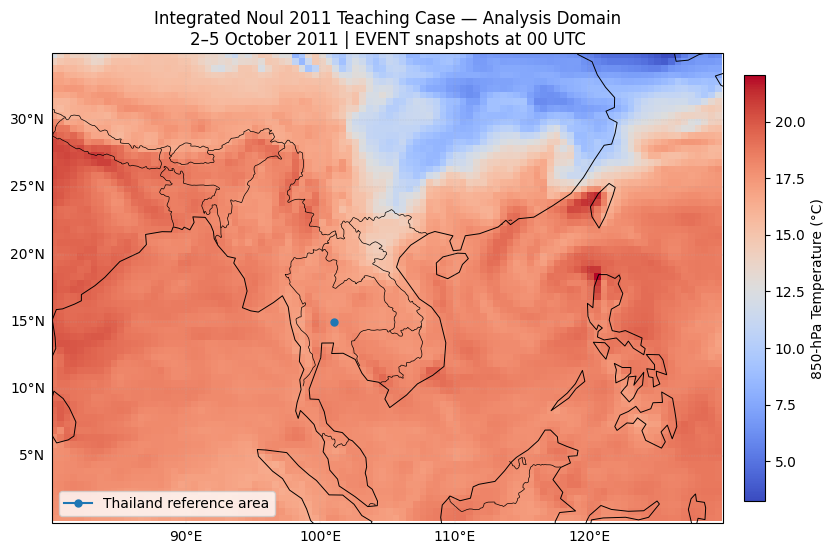

In [10]:
# CELL 10 — Case-study domain

reference_time = event_times[0]

reference_t = subset_domain(
    temperature_celsius(
        event_ds["t"].sel(
            time=reference_time,
            level=850,
        )
    ),
    SE_ASIA_DOMAIN,
)

fig = plt.figure(
    figsize=(10.5, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    reference_t["longitude"],
    reference_t["latitude"],
    reference_t,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

decorate_map(
    ax,
    SE_ASIA_DOMAIN,
)

ax.plot(
    101.0,
    15.0,
    marker="o",
    markersize=5,
    transform=ccrs.PlateCarree(),
    label="Thailand reference area",
)

ax.legend(
    loc="lower left"
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "850-hPa Temperature (°C)"
)

ax.set_title(
    "Integrated Noul 2011 Teaching Case — Analysis Domain\n"
    "2–5 October 2011 | EVENT snapshots at 00 UTC"
)

FIG_09_01 = (
    FIGURE_DIR
    / "09_01_case_study_domain.png"
)

plt.savefig(
    FIG_09_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 17. Figure 09-2 — 850-hPa Evolution: RH, Height and Wind

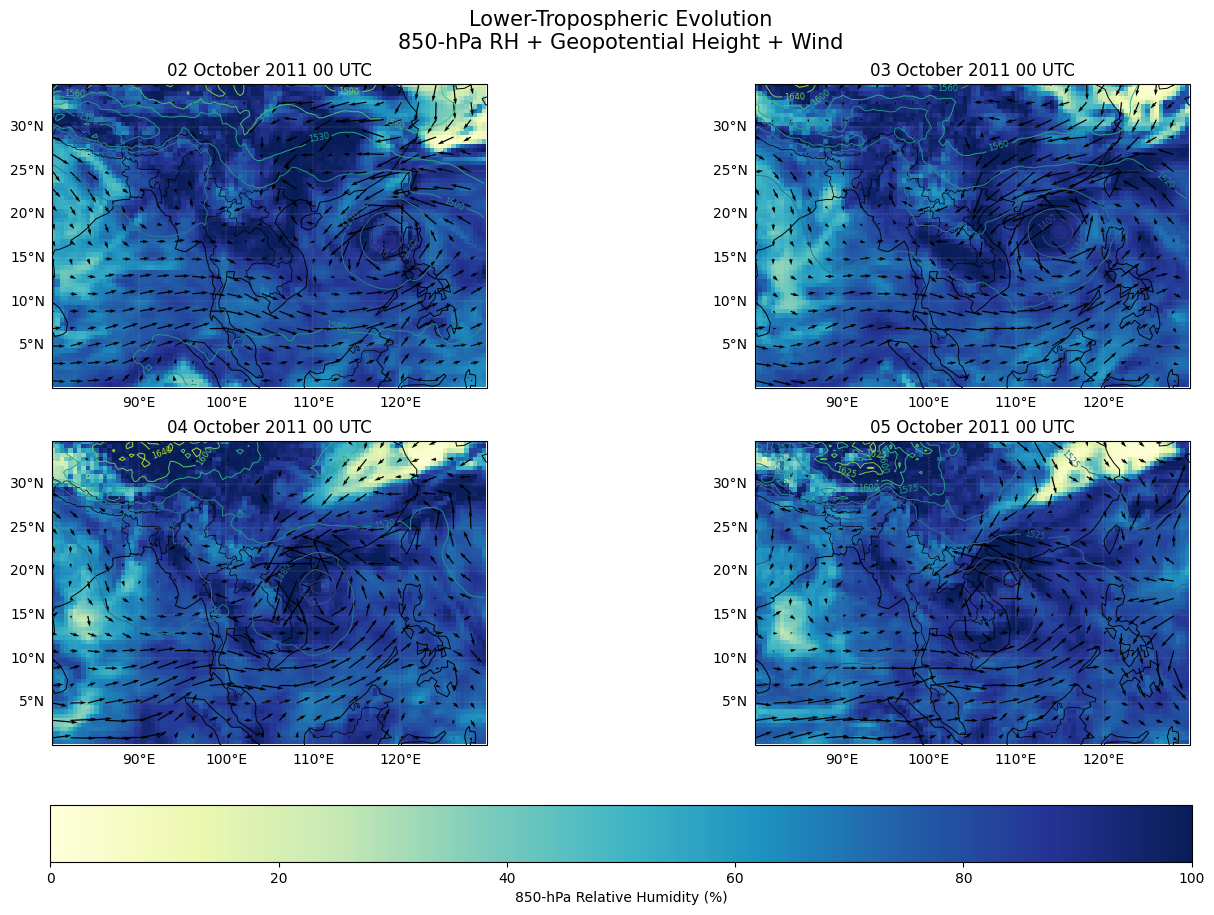

In [11]:
# CELL 11 — 850-hPa lower-tropospheric evolution

fields_850 = []

for time_value in event_times:
    rh = subset_domain(
        event_ds["r"].sel(
            time=time_value,
            level=850,
        ),
        SE_ASIA_DOMAIN,
    )

    height = subset_domain(
        geopotential_height(
            event_ds["z"].sel(
                time=time_value,
                level=850,
            )
        ),
        SE_ASIA_DOMAIN,
    )

    u = subset_domain(
        event_ds["u"].sel(
            time=time_value,
            level=850,
        ),
        SE_ASIA_DOMAIN,
    )

    v = subset_domain(
        event_ds["v"].sel(
            time=time_value,
            level=850,
        ),
        SE_ASIA_DOMAIN,
    )

    fields_850.append(
        {
            "time": time_value,
            "rh": rh,
            "height": height,
            "u": u,
            "v": v,
        }
    )

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, item in zip(
    axes,
    fields_850,
):
    mesh = ax.pcolormesh(
        item["rh"]["longitude"],
        item["rh"]["latitude"],
        item["rh"],
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
    )

    contours = ax.contour(
        item["height"]["longitude"],
        item["height"]["latitude"],
        item["height"],
        levels=8,
        transform=ccrs.PlateCarree(),
        linewidths=0.7,
    )

    ax.clabel(
        contours,
        inline=True,
        fontsize=6,
        fmt="%.0f",
    )

    ax.quiver(
        item["u"]["longitude"].values[::VECTOR_SKIP],
        item["u"]["latitude"].values[::VECTOR_SKIP],
        item["u"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        item["v"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        transform=ccrs.PlateCarree(),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        pd.Timestamp(
            item["time"]
        ).strftime(
            "%d %B %Y %H UTC"
        )
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.05,
    shrink=0.82,
)

cbar.set_label(
    "850-hPa Relative Humidity (%)"
)

fig.suptitle(
    "Lower-Tropospheric Evolution\n"
    "850-hPa RH + Geopotential Height + Wind",
    fontsize=15,
)

FIG_09_02 = (
    FIGURE_DIR
    / "09_02_850hPa_RH_height_wind_evolution.png"
)

plt.savefig(
    FIG_09_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 18. Figure 09-3 — 500-hPa Evolution: Relative Vorticity, Height and Wind

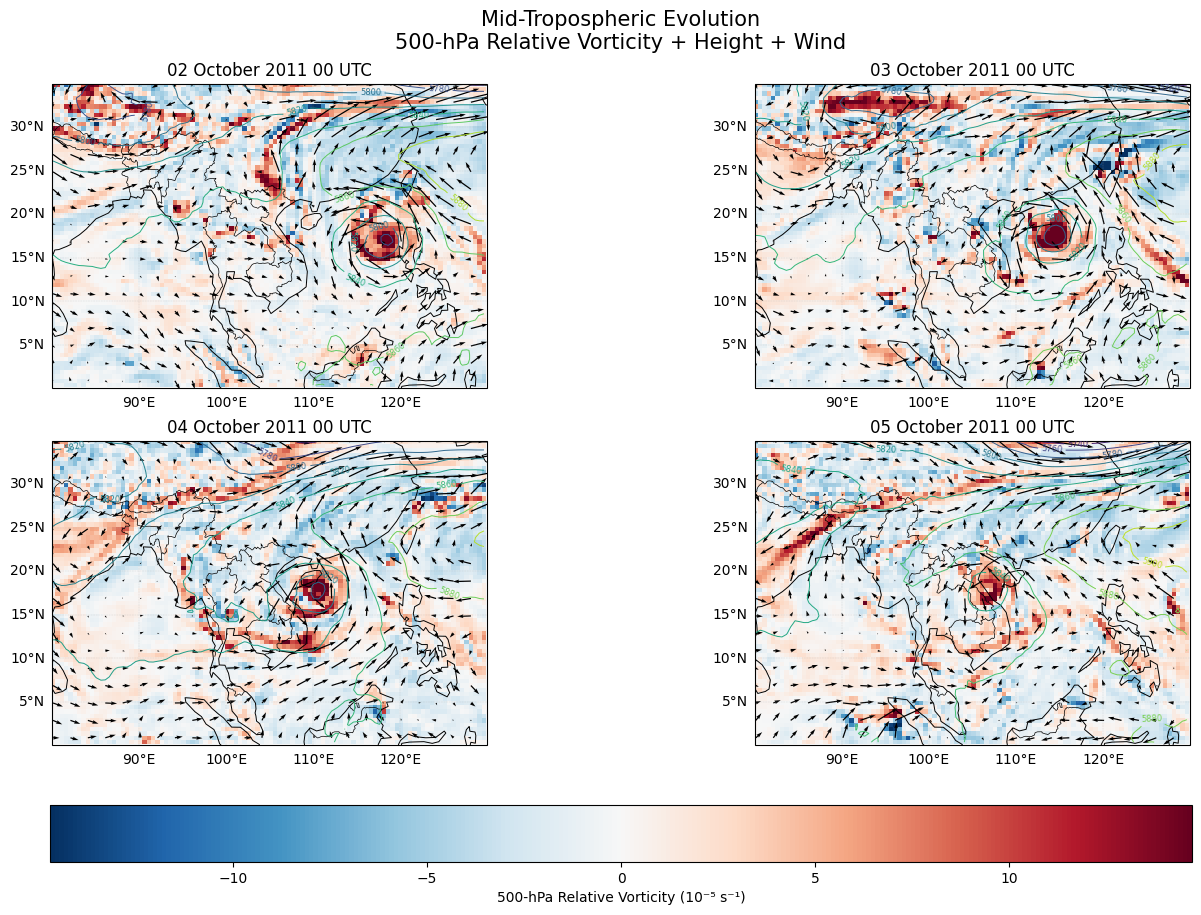

In [12]:
# CELL 12 — 500-hPa mid-tropospheric evolution

fields_500 = []

for time_value in event_times:
    vort = subset_domain(
        event_ds["vo"].sel(
            time=time_value,
            level=500,
        ),
        SE_ASIA_DOMAIN,
    )

    height = subset_domain(
        geopotential_height(
            event_ds["z"].sel(
                time=time_value,
                level=500,
            )
        ),
        SE_ASIA_DOMAIN,
    )

    u = subset_domain(
        event_ds["u"].sel(
            time=time_value,
            level=500,
        ),
        SE_ASIA_DOMAIN,
    )

    v = subset_domain(
        event_ds["v"].sel(
            time=time_value,
            level=500,
        ),
        SE_ASIA_DOMAIN,
    )

    fields_500.append(
        {
            "time": time_value,
            "vort": vort,
            "height": height,
            "u": u,
            "v": v,
        }
    )

vort_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                item["vort"].values * 1.0e5
            ),
            99,
        )
        for item in fields_500
    )
)

vort_abs = max(
    vort_abs,
    1.0,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, item in zip(
    axes,
    fields_500,
):
    scaled = item["vort"] * 1.0e5

    mesh = ax.pcolormesh(
        scaled["longitude"],
        scaled["latitude"],
        scaled,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(
            vmin=-vort_abs,
            vcenter=0.0,
            vmax=vort_abs,
        ),
    )

    contours = ax.contour(
        item["height"]["longitude"],
        item["height"]["latitude"],
        item["height"],
        levels=8,
        transform=ccrs.PlateCarree(),
        linewidths=0.7,
    )

    ax.clabel(
        contours,
        inline=True,
        fontsize=6,
        fmt="%.0f",
    )

    ax.quiver(
        item["u"]["longitude"].values[::VECTOR_SKIP],
        item["u"]["latitude"].values[::VECTOR_SKIP],
        item["u"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        item["v"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        transform=ccrs.PlateCarree(),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        pd.Timestamp(
            item["time"]
        ).strftime(
            "%d %B %Y %H UTC"
        )
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.05,
    shrink=0.82,
)

cbar.set_label(
    "500-hPa Relative Vorticity (10⁻⁵ s⁻¹)"
)

fig.suptitle(
    "Mid-Tropospheric Evolution\n"
    "500-hPa Relative Vorticity + Height + Wind",
    fontsize=15,
)

FIG_09_03 = (
    FIGURE_DIR
    / "09_03_500hPa_vorticity_height_wind_evolution.png"
)

plt.savefig(
    FIG_09_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 19. Figure 09-4 — 200-hPa Evolution: Divergence and Wind

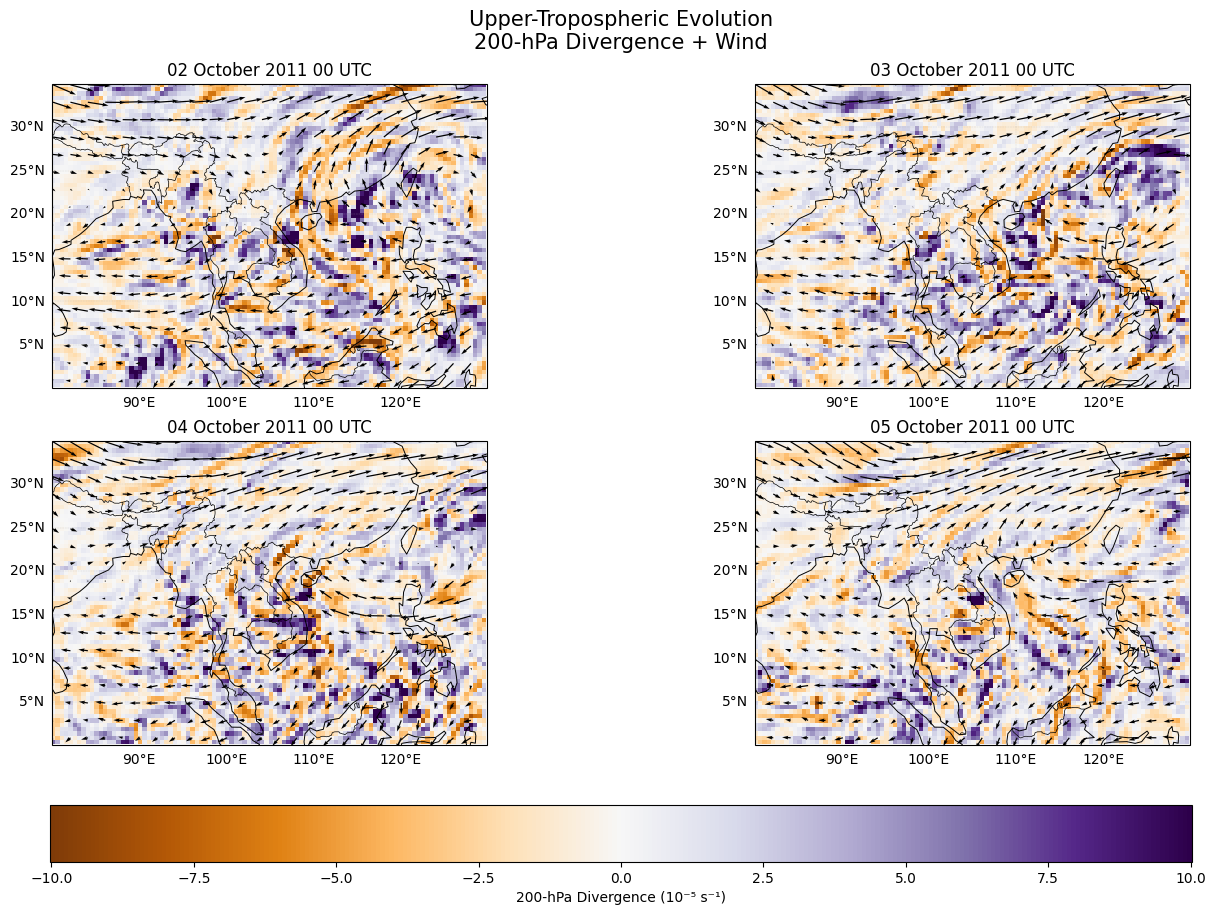

In [13]:
# CELL 13 — 200-hPa upper-tropospheric evolution

fields_200 = []

for time_value in event_times:
    div = subset_domain(
        event_ds["d"].sel(
            time=time_value,
            level=200,
        ),
        SE_ASIA_DOMAIN,
    )

    u = subset_domain(
        event_ds["u"].sel(
            time=time_value,
            level=200,
        ),
        SE_ASIA_DOMAIN,
    )

    v = subset_domain(
        event_ds["v"].sel(
            time=time_value,
            level=200,
        ),
        SE_ASIA_DOMAIN,
    )

    fields_200.append(
        {
            "time": time_value,
            "div": div,
            "u": u,
            "v": v,
        }
    )

div_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                item["div"].values * 1.0e5
            ),
            99,
        )
        for item in fields_200
    )
)

div_abs = max(
    div_abs,
    1.0,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, item in zip(
    axes,
    fields_200,
):
    scaled = item["div"] * 1.0e5

    mesh = ax.pcolormesh(
        scaled["longitude"],
        scaled["latitude"],
        scaled,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="PuOr",
        norm=TwoSlopeNorm(
            vmin=-div_abs,
            vcenter=0.0,
            vmax=div_abs,
        ),
    )

    ax.quiver(
        item["u"]["longitude"].values[::VECTOR_SKIP],
        item["u"]["latitude"].values[::VECTOR_SKIP],
        item["u"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        item["v"].values[::VECTOR_SKIP, ::VECTOR_SKIP],
        transform=ccrs.PlateCarree(),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        pd.Timestamp(
            item["time"]
        ).strftime(
            "%d %B %Y %H UTC"
        )
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.05,
    shrink=0.82,
)

cbar.set_label(
    "200-hPa Divergence (10⁻⁵ s⁻¹)"
)

fig.suptitle(
    "Upper-Tropospheric Evolution\n"
    "200-hPa Divergence + Wind",
    fontsize=15,
)

FIG_09_04 = (
    FIGURE_DIR
    / "09_04_200hPa_divergence_wind_evolution.png"
)

plt.savefig(
    FIG_09_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 20. Figure 09-5 — Vertical Synoptic Synthesis for 4 October 2011

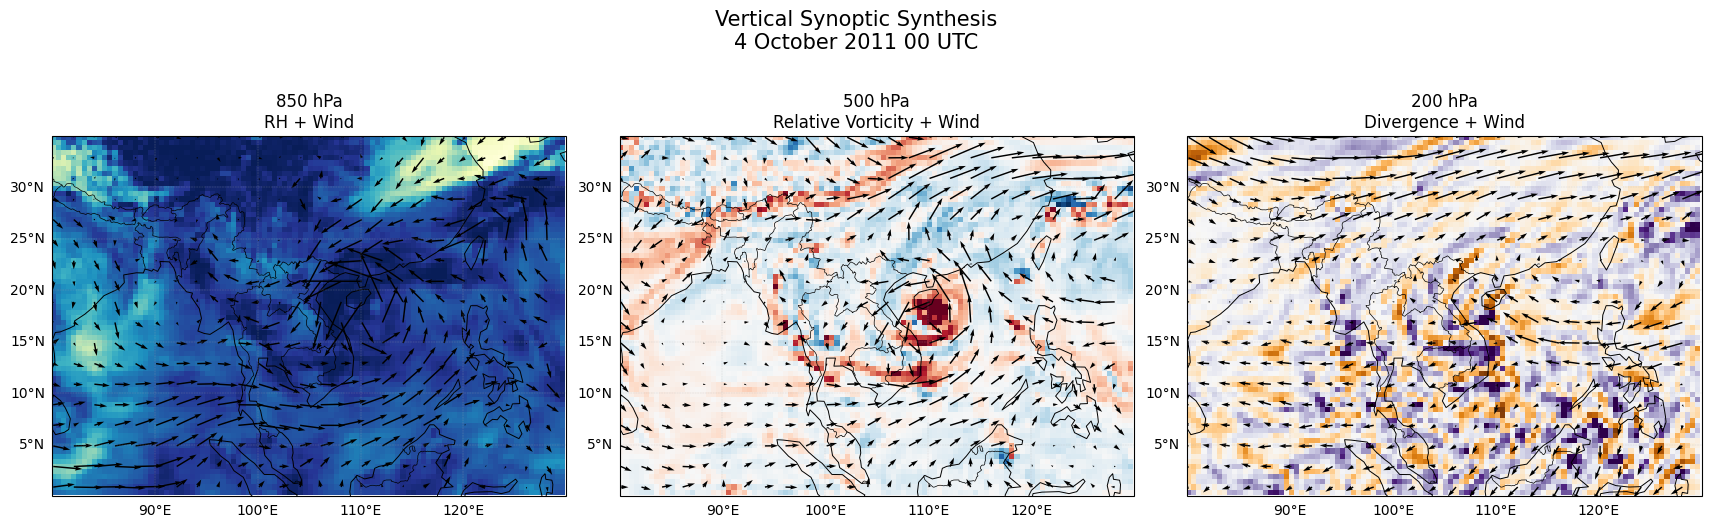

In [14]:
# CELL 14 — Vertical synthesis at one event time

SYNTHESIS_TIME = pd.Timestamp(
    "2011-10-04 00:00:00"
)

# 850 hPa
rh_850 = subset_domain(
    event_ds["r"].sel(
        time=SYNTHESIS_TIME,
        level=850,
    ),
    SE_ASIA_DOMAIN,
)

u_850 = subset_domain(
    event_ds["u"].sel(
        time=SYNTHESIS_TIME,
        level=850,
    ),
    SE_ASIA_DOMAIN,
)

v_850 = subset_domain(
    event_ds["v"].sel(
        time=SYNTHESIS_TIME,
        level=850,
    ),
    SE_ASIA_DOMAIN,
)

# 500 hPa
vort_500 = subset_domain(
    event_ds["vo"].sel(
        time=SYNTHESIS_TIME,
        level=500,
    ),
    SE_ASIA_DOMAIN,
) * 1.0e5

u_500 = subset_domain(
    event_ds["u"].sel(
        time=SYNTHESIS_TIME,
        level=500,
    ),
    SE_ASIA_DOMAIN,
)

v_500 = subset_domain(
    event_ds["v"].sel(
        time=SYNTHESIS_TIME,
        level=500,
    ),
    SE_ASIA_DOMAIN,
)

# 200 hPa
div_200 = subset_domain(
    event_ds["d"].sel(
        time=SYNTHESIS_TIME,
        level=200,
    ),
    SE_ASIA_DOMAIN,
) * 1.0e5

u_200 = subset_domain(
    event_ds["u"].sel(
        time=SYNTHESIS_TIME,
        level=200,
    ),
    SE_ASIA_DOMAIN,
)

v_200 = subset_domain(
    event_ds["v"].sel(
        time=SYNTHESIS_TIME,
        level=200,
    ),
    SE_ASIA_DOMAIN,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5.7),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

# 850
mesh_850 = axes[0].pcolormesh(
    rh_850["longitude"],
    rh_850["latitude"],
    rh_850,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
)

axes[0].quiver(
    u_850["longitude"].values[::VECTOR_SKIP],
    u_850["latitude"].values[::VECTOR_SKIP],
    u_850.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    v_850.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    axes[0],
    SE_ASIA_DOMAIN,
)

axes[0].set_title(
    "850 hPa\nRH + Wind"
)

# 500
mesh_500 = axes[1].pcolormesh(
    vort_500["longitude"],
    vort_500["latitude"],
    vort_500,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-vort_abs,
        vcenter=0.0,
        vmax=vort_abs,
    ),
)

axes[1].quiver(
    u_500["longitude"].values[::VECTOR_SKIP],
    u_500["latitude"].values[::VECTOR_SKIP],
    u_500.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    v_500.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    axes[1],
    SE_ASIA_DOMAIN,
)

axes[1].set_title(
    "500 hPa\nRelative Vorticity + Wind"
)

# 200
mesh_200 = axes[2].pcolormesh(
    div_200["longitude"],
    div_200["latitude"],
    div_200,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="PuOr",
    norm=TwoSlopeNorm(
        vmin=-div_abs,
        vcenter=0.0,
        vmax=div_abs,
    ),
)

axes[2].quiver(
    u_200["longitude"].values[::VECTOR_SKIP],
    u_200["latitude"].values[::VECTOR_SKIP],
    u_200.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    v_200.values[::VECTOR_SKIP, ::VECTOR_SKIP],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    axes[2],
    SE_ASIA_DOMAIN,
)

axes[2].set_title(
    "200 hPa\nDivergence + Wind"
)

fig.suptitle(
    "Vertical Synoptic Synthesis\n"
    "4 October 2011 00 UTC",
    fontsize=15,
)

FIG_09_05 = (
    FIGURE_DIR
    / "09_05_vertical_synoptic_synthesis_20111004.png"
)

plt.savefig(
    FIG_09_05,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 21. Event-Window Hovmöller

In [15]:
# CELL 15 — Build Time–Longitude Hovmöller

u850 = spatiotemporal_ds["u"]

u_lat_band = u850.sel(
    latitude=coordinate_slice(
        u850["latitude"],
        HOV_LAT_BAND["lat_min"],
        HOV_LAT_BAND["lat_max"],
    )
)

lat_weights = np.cos(
    np.deg2rad(
        u_lat_band["latitude"]
    )
)

hov_time_lon = (
    u_lat_band
    .weighted(
        lat_weights
    )
    .mean(
        dim="latitude"
    )
)

hov_event = hov_time_lon.sel(
    time=slice(
        EVENT_WINDOW_START,
        EVENT_WINDOW_END,
    )
)

print(
    hov_event
)

<xarray.DataArray 'u' (time: 64, longitude: 240)> Size: 61kB
array([[  1.3227999 ,   0.64148635,   0.8602617 , ...,  -9.659002  ,
         -9.612997  ,  -9.606187  ],
       [  0.48295885,   0.80757827,   1.0955224 , ...,  -9.941219  ,
         -9.921734  ,  -9.8883    ],
       [  0.4157242 ,   1.0046252 ,   1.3408254 , ..., -10.861717  ,
        -10.847588  , -10.924976  ],
       ...,
       [ -3.1610606 ,  -3.0823653 ,  -3.0135133 , ..., -10.221518  ,
        -10.668359  , -10.881532  ],
       [ -3.563606  ,  -3.10629   ,  -2.6240962 , ...,  -9.291282  ,
         -9.273688  ,  -9.328567  ],
       [ -1.8670775 ,  -2.0331433 ,  -2.2711573 , ...,  -8.482243  ,
         -8.509253  ,  -8.439405  ]], dtype=float32)
Coordinates:
  * time                       (time) datetime64[ns] 512B 2011-09-25 ... 2011...
  * longitude                  (longitude) float32 960B 40.12 40.62 ... 159.6
    source_pressure_level_hPa  float64 8B 850.0
Attributes:
    units:          m s**-1
    long_name: 

# 22. Figure 09-6 — Event-Window Time–Longitude Hovmöller

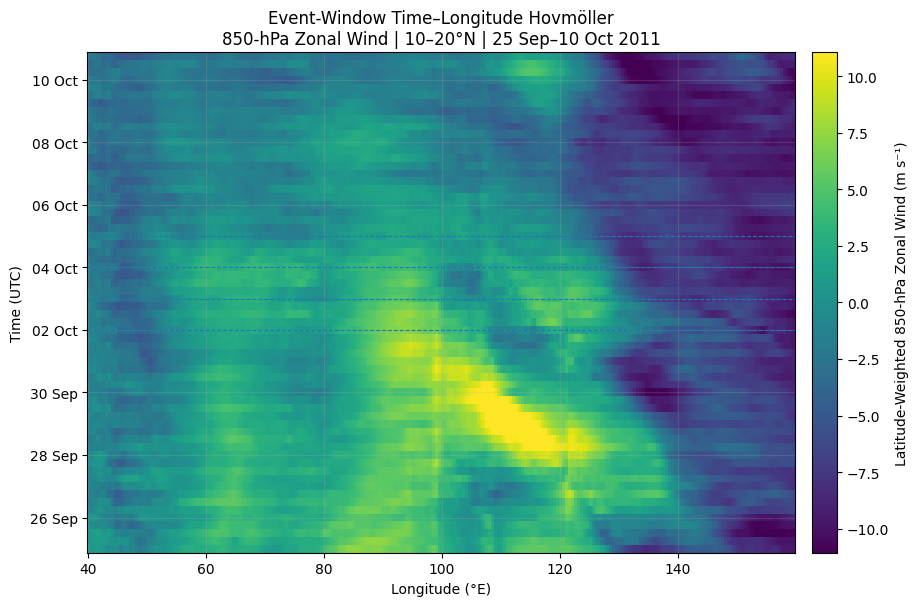

In [16]:
# CELL 16 — Event-window Hovmöller

hov_abs = float(
    np.nanpercentile(
        np.abs(
            hov_event.values
        ),
        99,
    )
)

hov_abs = max(
    hov_abs,
    1.0,
)

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

mesh = ax.pcolormesh(
    hov_event["longitude"],
    hov_event["time"],
    hov_event,
    shading="auto",
    norm=TwoSlopeNorm(
        vmin=-hov_abs,
        vcenter=0.0,
        vmax=hov_abs,
    ),
)

for time_value in event_times:
    ax.axhline(
        pd.Timestamp(
            time_value
        ),
        linewidth=0.8,
        linestyle="--",
    )

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Latitude-Weighted 850-hPa Zonal Wind (m s⁻¹)"
)

ax.set_xlabel(
    "Longitude (°E)"
)

ax.set_ylabel(
    "Time (UTC)"
)

ax.set_title(
    "Event-Window Time–Longitude Hovmöller\n"
    "850-hPa Zonal Wind | 10–20°N | 25 Sep–10 Oct 2011"
)

ax.yaxis.set_major_locator(
    mdates.DayLocator(
        interval=2
    )
)

ax.yaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b"
    )
)

ax.grid(
    True,
    alpha=0.2,
)

FIG_09_06 = (
    FIGURE_DIR
    / "09_06_event_window_hovmoller_u850.png"
)

plt.savefig(
    FIG_09_06,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 23. การเชื่อม Hovmöller กับ Synoptic Maps

เส้นแนวนอนใน Figure 09-6 คือเวลาเดียวกับ EVENT snapshots:

```text
2 Oct 00 UTC
3 Oct 00 UTC
4 Oct 00 UTC
5 Oct 00 UTC
```

ขั้นตอนการตีความ:

```text
Hovmöller feature
→ เลือกเวลา
→ กลับไปดู map
→ ตรวจ spatial pattern
→ สังเคราะห์ร่วมกับ pressure levels
```

# 24. Figure 09-7 — Thailand-Area Mean u850 Time Series

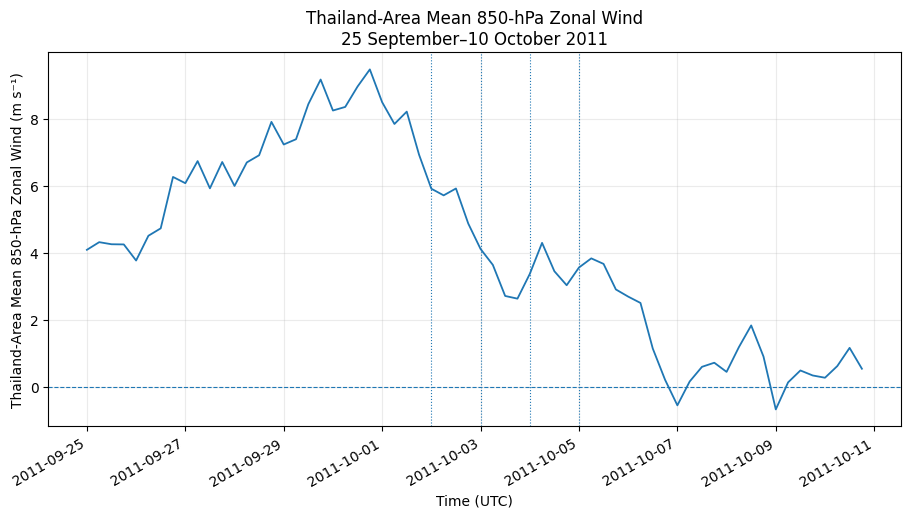

In [17]:
# CELL 17 — Thailand-area mean 6-hourly u850

u_thailand = subset_domain(
    spatiotemporal_ds["u"],
    THAILAND_BOX,
)

thai_weights = np.cos(
    np.deg2rad(
        u_thailand["latitude"]
    )
)

u_thailand_mean = (
    u_thailand
    .weighted(
        thai_weights
    )
    .mean(
        dim=(
            "latitude",
            "longitude",
        )
    )
)

u_event_window = u_thailand_mean.sel(
    time=slice(
        EVENT_WINDOW_START,
        EVENT_WINDOW_END,
    )
)

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

ax.plot(
    u_event_window["time"],
    u_event_window,
    linewidth=1.3,
)

ax.axhline(
    0.0,
    linewidth=0.8,
    linestyle="--",
)

for time_value in event_times:
    ax.axvline(
        pd.Timestamp(
            time_value
        ),
        linewidth=0.8,
        linestyle=":",
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Thailand-Area Mean 850-hPa Zonal Wind (m s⁻¹)"
)

ax.set_title(
    "Thailand-Area Mean 850-hPa Zonal Wind\n"
    "25 September–10 October 2011"
)

ax.grid(
    True,
    alpha=0.25,
)

fig.autofmt_xdate()

FIG_09_07 = (
    FIGURE_DIR
    / "09_07_thailand_area_u850_event_time_series.png"
)

plt.savefig(
    FIG_09_07,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 25. Regional Event Diagnostics

In [18]:
# CELL 18 — Regional diagnostics for each EVENT snapshot

diagnostic_rows = []

for time_value in event_times:
    rh850 = event_ds["r"].sel(
        time=time_value,
        level=850,
    )

    t850 = temperature_celsius(
        event_ds["t"].sel(
            time=time_value,
            level=850,
        )
    )

    u850_event = event_ds["u"].sel(
        time=time_value,
        level=850,
    )

    v850_event = event_ds["v"].sel(
        time=time_value,
        level=850,
    )

    wind850 = wind_speed(
        u850_event,
        v850_event,
    )

    vort500 = event_ds["vo"].sel(
        time=time_value,
        level=500,
    )

    div200 = event_ds["d"].sel(
        time=time_value,
        level=200,
    )

    diagnostic_rows.append(
        {
            "time_UTC": pd.Timestamp(
                time_value
            ),
            "T850_mean_C": float(
                weighted_regional_mean(
                    t850,
                    THAILAND_BOX,
                )
            ),
            "RH850_mean_pct": float(
                weighted_regional_mean(
                    rh850,
                    THAILAND_BOX,
                )
            ),
            "wind850_mean_ms": float(
                weighted_regional_mean(
                    wind850,
                    THAILAND_BOX,
                )
            ),
            "vorticity500_mean_1e-5_s-1": float(
                weighted_regional_mean(
                    vort500,
                    THAILAND_BOX,
                )
                * 1.0e5
            ),
            "divergence200_mean_1e-5_s-1": float(
                weighted_regional_mean(
                    div200,
                    THAILAND_BOX,
                )
                * 1.0e5
            ),
        }
    )

EVENT_DIAGNOSTICS = pd.DataFrame(
    diagnostic_rows
)

display(
    EVENT_DIAGNOSTICS
)

,time_UTC,T850_mean_C,RH850_mean_pct,wind850_mean_ms,vorticity500_mean_1e-5_s-1,divergence200_mean_1e-5_s-1
0,2011-10-02,17.619726,82.227554,7.595492,0.028694,0.298469
1,2011-10-03,17.504515,83.685379,8.269012,-0.115865,0.833873
2,2011-10-04,16.947708,82.688782,8.226602,-0.077306,0.661609
3,2011-10-05,16.955780,83.848785,6.448769,0.203989,0.672060


# 26. Figure 09-8 — Regional Diagnostic Evolution

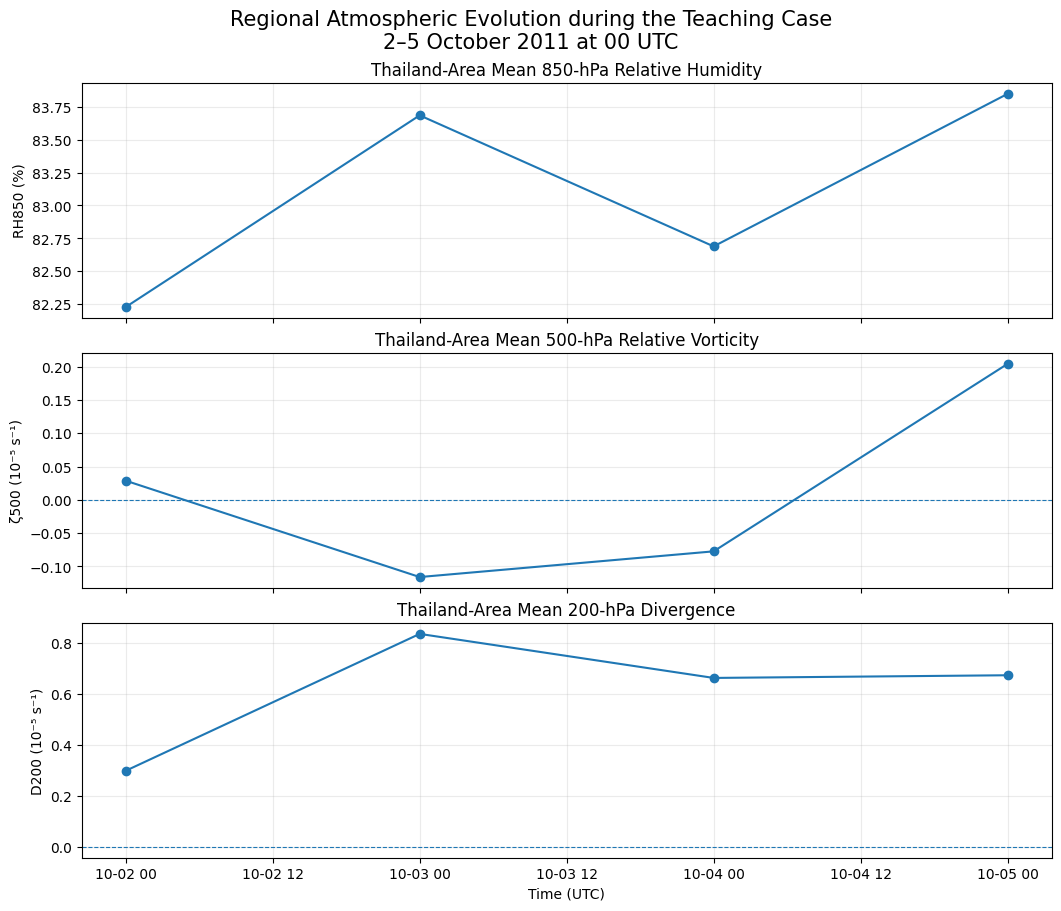

In [19]:
# CELL 19 — Regional diagnostic evolution figure

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10.5, 9),
    sharex=True,
    constrained_layout=True,
)

axes[0].plot(
    EVENT_DIAGNOSTICS["time_UTC"],
    EVENT_DIAGNOSTICS["RH850_mean_pct"],
    marker="o",
)

axes[0].set_ylabel(
    "RH850 (%)"
)

axes[0].set_title(
    "Thailand-Area Mean 850-hPa Relative Humidity"
)

axes[0].grid(
    True,
    alpha=0.25,
)

axes[1].plot(
    EVENT_DIAGNOSTICS["time_UTC"],
    EVENT_DIAGNOSTICS[
        "vorticity500_mean_1e-5_s-1"
    ],
    marker="o",
)

axes[1].axhline(
    0.0,
    linewidth=0.8,
    linestyle="--",
)

axes[1].set_ylabel(
    "ζ500 (10⁻⁵ s⁻¹)"
)

axes[1].set_title(
    "Thailand-Area Mean 500-hPa Relative Vorticity"
)

axes[1].grid(
    True,
    alpha=0.25,
)

axes[2].plot(
    EVENT_DIAGNOSTICS["time_UTC"],
    EVENT_DIAGNOSTICS[
        "divergence200_mean_1e-5_s-1"
    ],
    marker="o",
)

axes[2].axhline(
    0.0,
    linewidth=0.8,
    linestyle="--",
)

axes[2].set_ylabel(
    "D200 (10⁻⁵ s⁻¹)"
)

axes[2].set_xlabel(
    "Time (UTC)"
)

axes[2].set_title(
    "Thailand-Area Mean 200-hPa Divergence"
)

axes[2].grid(
    True,
    alpha=0.25,
)

fig.suptitle(
    "Regional Atmospheric Evolution during the Teaching Case\n"
    "2–5 October 2011 at 00 UTC",
    fontsize=15,
)

FIG_09_08 = (
    FIGURE_DIR
    / "09_08_regional_diagnostic_evolution.png"
)

plt.savefig(
    FIG_09_08,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 27. Observation → Interpretation → Limitation Framework

In [20]:
# CELL 20 — Scientific interpretation framework

INTERPRETATION_FRAMEWORK = pd.DataFrame(
    [
        {
            "evidence": "850-hPa RH + height + wind",
            "observation_question": (
                "Where are moist lower-tropospheric air and organized flow located?"
            ),
            "interpretation_scope": (
                "Lower-tropospheric moisture and circulation structure"
            ),
            "limitation": (
                "High RH alone does not prove rainfall or deep convection."
            ),
        },
        {
            "evidence": "500-hPa relative vorticity + height + wind",
            "observation_question": (
                "Where does cyclonic or anticyclonic relative rotation occur?"
            ),
            "interpretation_scope": (
                "Mid-tropospheric rotational and geopotential structure"
            ),
            "limitation": (
                "Positive relative vorticity alone does not prove ascent."
            ),
        },
        {
            "evidence": "200-hPa divergence + wind",
            "observation_question": (
                "Where is upper-level horizontal divergence or convergence present?"
            ),
            "interpretation_scope": (
                "Upper-tropospheric horizontal mass-flow tendency"
            ),
            "limitation": (
                "Divergence at one pressure level is not vertical velocity."
            ),
        },
        {
            "evidence": "Time–Longitude Hovmöller of u850",
            "observation_question": (
                "How does the zonal-flow pattern vary with longitude and time?"
            ),
            "interpretation_scope": (
                "Spatiotemporal context of the zonal wind component"
            ),
            "limitation": (
                "u850 is not total wind and latitude averaging removes spatial detail."
            ),
        },
        {
            "evidence": "Thailand-area diagnostic means",
            "observation_question": (
                "How do selected regional mean diagnostics change from 2 to 5 October?"
            ),
            "interpretation_scope": (
                "Compact regional summary of the event snapshots"
            ),
            "limitation": (
                "Regional averaging can hide important local and spatial structures."
            ),
        },
    ]
)

display(
    INTERPRETATION_FRAMEWORK
)

,evidence,observation_question,interpretation_scope,limitation
0,850-hPa RH + height + wind,Where are moist lower-tropospheric air and org...,Lower-tropospheric moisture and circulation st...,High RH alone does not prove rainfall or deep ...
1,500-hPa relative vorticity + height + wind,Where does cyclonic or anticyclonic relative r...,Mid-tropospheric rotational and geopotential s...,Positive relative vorticity alone does not pro...
2,200-hPa divergence + wind,Where is upper-level horizontal divergence or ...,Upper-tropospheric horizontal mass-flow tendency,Divergence at one pressure level is not vertic...
3,Time–Longitude Hovmöller of u850,How does the zonal-flow pattern vary with long...,Spatiotemporal context of the zonal wind compo...,u850 is not total wind and latitude averaging ...
4,Thailand-area diagnostic means,How do selected regional mean diagnostics chan...,Compact regional summary of the event snapshots,Regional averaging can hide important local an...


# 28. Integrated Case-Study Writing Template

ให้นิสิตเขียนผลการวิเคราะห์โดยใช้ลำดับนี้:

```text
A. Data and temporal coverage
B. Lower-tropospheric structure
C. Mid-tropospheric structure
D. Upper-tropospheric structure
E. Spatiotemporal context
F. Vertical synthesis
G. Limitations
```

ตัวอย่างภาษาที่เหมาะสม:

> “At 850 hPa, the ERA5 fields show …”

> “The 500-hPa relative-vorticity field is consistent with …”

> “Upper-level divergence is present over …; however, this field alone does not establish vertical motion.”

> “The Hovmöller diagram indicates a changing zonal-wind pattern through the event window, which is examined together with the synoptic maps.”

หลีกเลี่ยงคำที่เกินหลักฐาน เช่น:

```text
proved
caused
definitely
confirmed severe convection
```

ถ้ายังไม่มีข้อมูลสนับสนุนโดยตรง

# 29. Case-Study Limitation Table

In [21]:
# CELL 21 — Case-study limitations

CASE_LIMITATIONS = pd.DataFrame(
    [
        {
            "issue": "EVENT temporal sampling",
            "limitation": (
                "Only four 00-UTC snapshots from 2–5 October 2011."
            ),
            "implication": (
                "Cannot reconstruct the complete 24-hour evolution of each day."
            ),
        },
        {
            "issue": "Spatiotemporal variable",
            "limitation": (
                "Only the 850-hPa zonal wind component u is available."
            ),
            "implication": (
                "Cannot derive total horizontal wind from this file alone."
            ),
        },
        {
            "issue": "October climatology",
            "limitation": (
                "The monthly archive contains January and July only."
            ),
            "implication": (
                "No October 2011 climatological anomaly is computed."
            ),
        },
        {
            "issue": "Cyclone/storm track",
            "limitation": (
                "No storm-track dataset is included in the prepared teaching files."
            ),
            "implication": (
                "The notebook does not diagnose or verify a storm center/track."
            ),
        },
        {
            "issue": "850-hPa terrain",
            "limitation": (
                "850 hPa can lie below ground over high terrain."
            ),
            "implication": (
                "Interpret low-level fields cautiously over elevated terrain."
            ),
        },
        {
            "issue": "Regional means",
            "limitation": (
                "Area averaging reduces spatial variability."
            ),
            "implication": (
                "Use maps together with summary time series."
            ),
        },
    ]
)

display(
    CASE_LIMITATIONS
)

,issue,limitation,implication
0,EVENT temporal sampling,Only four 00-UTC snapshots from 2–5 October 2011.,Cannot reconstruct the complete 24-hour evolut...
1,Spatiotemporal variable,Only the 850-hPa zonal wind component u is ava...,Cannot derive total horizontal wind from this ...
2,October climatology,The monthly archive contains January and July ...,No October 2011 climatological anomaly is comp...
3,Cyclone/storm track,No storm-track dataset is included in the prep...,The notebook does not diagnose or verify a sto...
4,850-hPa terrain,850 hPa can lie below ground over high terrain.,Interpret low-level fields cautiously over ele...
5,Regional means,Area averaging reduces spatial variability.,Use maps together with summary time series.


# 30. Export Case-Study Products

In [22]:
# CELL 22 — Export case-study tables

EVENT_DIAGNOSTICS_CSV = (
    OUTPUT_DIR
    / "09_event_regional_diagnostics.csv"
)

INTERPRETATION_FRAMEWORK_CSV = (
    OUTPUT_DIR
    / "09_interpretation_framework.csv"
)

CASE_LIMITATIONS_CSV = (
    OUTPUT_DIR
    / "09_case_study_limitations.csv"
)

CASE_METADATA_CSV = (
    METADATA_DIR
    / "09_case_study_metadata.csv"
)

EVENT_DIAGNOSTICS.to_csv(
    EVENT_DIAGNOSTICS_CSV,
    index=False,
)

INTERPRETATION_FRAMEWORK.to_csv(
    INTERPRETATION_FRAMEWORK_CSV,
    index=False,
)

CASE_LIMITATIONS.to_csv(
    CASE_LIMITATIONS_CSV,
    index=False,
)

print(
    "Saved:",
    EVENT_DIAGNOSTICS_CSV,
)

print(
    "Saved:",
    INTERPRETATION_FRAMEWORK_CSV,
)

print(
    "Saved:",
    CASE_LIMITATIONS_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/09_event_regional_diagnostics.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/09_interpretation_framework.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/09_case_study_limitations.csv


In [23]:
# CELL 23 — Export derived spatiotemporal context

DERIVED_NETCDF = (
    OUTPUT_DIR
    / "09_case_study_spatiotemporal_context.nc"
)

derived_ds = xr.Dataset(
    {
        "u850_time_longitude_event_window": (
            hov_event
        ),
        "u850_thailand_area_mean_event_window": (
            u_event_window
        ),
    }
)

derived_ds.attrs.update(
    {
        "course": (
            "Teaching ERA5 Reanalysis and GIS"
        ),
        "notebook": (
            "09 Integrated Noul 2011 Case Study"
        ),
        "event_snapshot_period": (
            "2–5 October 2011 at 00 UTC"
        ),
        "spatiotemporal_context_period": (
            "25 September–10 October 2011"
        ),
        "hovmoller_latitude_band": (
            "10–20°N"
        ),
        "regional_box": (
            "97–106°E, 5–21°N"
        ),
        "october_anomaly_policy": (
            "No October climatological anomaly computed"
        ),
    }
)

encoding = {
    variable_name: {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    }
    for variable_name
    in derived_ds.data_vars
}

derived_ds.to_netcdf(
    DERIVED_NETCDF,
    engine="netcdf4",
    encoding=encoding,
)

print(
    "Saved:",
    DERIVED_NETCDF,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/09_case_study_spatiotemporal_context.nc


In [24]:
# CELL 24 — Export case-study metadata

CASE_METADATA = pd.DataFrame(
    [
        {
            "parameter": "EVENT_file",
            "value": EVENT_FILE.name,
        },
        {
            "parameter": "SPATIOTEMPORAL_file",
            "value": SPATIOTEMPORAL_FILE.name,
        },
        {
            "parameter": "event_temporal_semantics",
            "value": (
                "Four daily 00-UTC synoptic snapshots; not daily means"
            ),
        },
        {
            "parameter": "spatiotemporal_cadence_hours",
            "value": spatiotemporal_step_hours,
        },
        {
            "parameter": "analysis_domain",
            "value": str(
                SE_ASIA_DOMAIN
            ),
        },
        {
            "parameter": "Thailand_box",
            "value": str(
                THAILAND_BOX
            ),
        },
        {
            "parameter": "Hovmoller_latitude_band",
            "value": str(
                HOV_LAT_BAND
            ),
        },
        {
            "parameter": "October_climatology_available",
            "value": OCTOBER_CLIMATOLOGY_AVAILABLE,
        },
        {
            "parameter": "October_anomaly_policy",
            "value": (
                "Do not compute October climatological anomaly"
            ),
        },
        {
            "parameter": "storm_track_policy",
            "value": (
                "No storm-track verification because no track dataset is included"
            ),
        },
    ]
)

CASE_METADATA.to_csv(
    CASE_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    CASE_METADATA_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/09_case_study_metadata.csv


# 31. Figure Manifest

In [25]:
# CELL 25 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "09-01",
            "file": str(
                FIG_09_01
            ),
            "description": (
                "Case-study domain and event orientation"
            ),
        },
        {
            "figure": "09-02",
            "file": str(
                FIG_09_02
            ),
            "description": (
                "850-hPa RH, geopotential height and wind evolution"
            ),
        },
        {
            "figure": "09-03",
            "file": str(
                FIG_09_03
            ),
            "description": (
                "500-hPa relative vorticity, height and wind evolution"
            ),
        },
        {
            "figure": "09-04",
            "file": str(
                FIG_09_04
            ),
            "description": (
                "200-hPa divergence and wind evolution"
            ),
        },
        {
            "figure": "09-05",
            "file": str(
                FIG_09_05
            ),
            "description": (
                "Vertical synoptic synthesis for 4 October 2011"
            ),
        },
        {
            "figure": "09-06",
            "file": str(
                FIG_09_06
            ),
            "description": (
                "Event-window Time–Longitude Hovmöller of u850"
            ),
        },
        {
            "figure": "09-07",
            "file": str(
                FIG_09_07
            ),
            "description": (
                "Thailand-area mean 850-hPa zonal-wind time series"
            ),
        },
        {
            "figure": "09-08",
            "file": str(
                FIG_09_08
            ),
            "description": (
                "Regional diagnostic evolution at 850, 500 and 200 hPa"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "09_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,09-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Case-study domain and event orientation
1,09-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"850-hPa RH, geopotential height and wind evolu..."
2,09-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"500-hPa relative vorticity, height and wind ev..."
3,09-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,200-hPa divergence and wind evolution
4,09-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Vertical synoptic synthesis for 4 October 2011
5,09-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Event-window Time–Longitude Hovmöller of u850
6,09-07,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Thailand-area mean 850-hPa zonal-wind time series
7,09-08,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"Regional diagnostic evolution at 850, 500 and ..."


# 32. Common Mistakes

### Mistake 1
เรียก EVENT 4 time steps ว่า daily means

จริง ๆ คือ:

```text
2, 3, 4, 5 October 2011
at 00 UTC only
```

### Mistake 2
ใช้ $u_{850}$ จาก spatiotemporal file เป็น total wind speed

### Mistake 3
เห็น positive 500-hPa vorticity แล้วสรุปว่ามี ascent โดยตรง

### Mistake 4
เห็น 200-hPa divergence แล้วสรุปว่าเกิด severe convection แน่นอน

### Mistake 5
อ่าน Hovmöller โดยไม่ย้อนกลับไปตรวจ spatial maps

### Mistake 6
ใช้ regional mean แทน spatial field ทั้งหมด

### Mistake 7
สร้าง October climatological anomaly จาก January/July baseline

### Mistake 8
ตีความชื่อไฟล์ `noul` เป็นการยืนยันตำแหน่งหรือ track ของ cyclone ทั้งที่ไม่มี storm-track dataset

### Mistake 9
ละเลยข้อจำกัดของ 850 hPa เหนือภูมิประเทศสูง

### Mistake 10
ใช้คำว่า “caused” ทั้งที่ผลลัพธ์เพียงแสดง atmospheric patterns ที่สอดคล้องกัน

# 33. Exercises

### Exercise 1 — Lower-Tropospheric Evolution

ใช้ Figure 09-2 เปรียบเทียบ 2 และ 5 October 2011 แล้วเขียน:

```text
Observation
Interpretation
Limitation
```

### Exercise 2 — Mid-Level Rotation

ใช้ Figure 09-3 ระบุบริเวณ positive relative vorticity ที่เด่นในแต่ละวัน

### Exercise 3 — Upper-Level Divergence

ใช้ Figure 09-4 เปรียบเทียบ pattern ของ divergence ระหว่าง 2–5 October

### Exercise 4 — Vertical Synthesis

ใช้ Figure 09-5 สรุป atmospheric structure วันที่ 4 October 2011 จาก:

```text
850 hPa
500 hPa
200 hPa
```

### Exercise 5 — Hovmöller

เลือก feature หนึ่งจาก Figure 09-6 แล้วอธิบายว่าต้องใช้ Figure 09-2 ร่วมกันอย่างไรเพื่อหลีกเลี่ยงการตีความผิด

### Exercise 6 — Regional Means

เปรียบเทียบ Figure 09-8 กับ spatial maps และหาตัวอย่างอย่างน้อยหนึ่งกรณีที่ regional mean ซ่อน spatial variation

### Exercise 7 — October Baseline

อธิบายอย่างน้อย 3 เหตุผลว่าทำไม Notebook 09 ไม่สร้าง October climatological anomaly

### Exercise 8 — Mini Research Summary

เขียนบทสรุป 250–400 คำ โดยใช้โครง:

```text
Data
→ Lower atmosphere
→ Mid atmosphere
→ Upper atmosphere
→ Spatiotemporal context
→ Synthesis
→ Limitations
```

# 34. Final Readiness Check

In [26]:
# CELL 26 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


required_event_variables = {
    "t",
    "r",
    "z",
    "u",
    "v",
    "vo",
    "d",
}

required_event_levels = {
    850,
    500,
    200,
}

available_event_levels = set(
    int(
        value
    )
    for value in np.atleast_1d(
        event_ds["level"].values
    )
)

add_check(
    "EVENT dataset opened",
    isinstance(
        event_ds,
        xr.Dataset,
    ),
)

add_check(
    "SPATIOTEMPORAL dataset opened",
    isinstance(
        spatiotemporal_ds,
        xr.Dataset,
    ),
)

add_check(
    "Required EVENT variables available",
    required_event_variables.issubset(
        set(
            event_ds.data_vars
        )
    ),
)

add_check(
    "Required pressure levels available",
    required_event_levels.issubset(
        available_event_levels
    ),
)

add_check(
    "EVENT contains four snapshots",
    event_ds.sizes["time"] == 4,
)

add_check(
    "EVENT snapshots are at 00 UTC",
    all(
        pd.Timestamp(
            time_value
        ).hour
        == 0
        for time_value in event_times
    ),
)

add_check(
    "Spatiotemporal cadence is 6 hours",
    np.isclose(
        spatiotemporal_step_hours,
        6.0,
    ),
)

add_check(
    "October climatology correctly not used",
    not OCTOBER_CLIMATOLOGY_AVAILABLE,
)

for figure_path, label in [
    (
        FIG_09_01,
        "Case-study domain",
    ),
    (
        FIG_09_02,
        "850-hPa evolution",
    ),
    (
        FIG_09_03,
        "500-hPa evolution",
    ),
    (
        FIG_09_04,
        "200-hPa evolution",
    ),
    (
        FIG_09_05,
        "Vertical synthesis",
    ),
    (
        FIG_09_06,
        "Event Hovmöller",
    ),
    (
        FIG_09_07,
        "Thailand-area u850 series",
    ),
    (
        FIG_09_08,
        "Regional diagnostic evolution",
    ),
]:
    add_check(
        f"{label} figure exported",
        figure_path.exists(),
    )

add_check(
    "Event diagnostic CSV exported",
    EVENT_DIAGNOSTICS_CSV.exists(),
)

add_check(
    "Derived context NetCDF exported",
    DERIVED_NETCDF.exists(),
)

add_check(
    "Case-study metadata exported",
    CASE_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "09_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 09 READY"
    )

    print(
        "ERA5 TEACHING CORE COURSE 00–09 COMPLETE"
    )

else:
    print(
        "NOTEBOOK 09 REQUIRES REVIEW"
    )

,item,status,note
0,EVENT dataset opened,PASS,
1,SPATIOTEMPORAL dataset opened,PASS,
2,Required EVENT variables available,PASS,
3,Required pressure levels available,PASS,
4,EVENT contains four snapshots,PASS,
5,EVENT snapshots are at 00 UTC,PASS,
6,Spatiotemporal cadence is 6 hours,PASS,
7,October climatology correctly not used,PASS,
8,Case-study domain figure exported,PASS,
9,850-hPa evolution figure exported,PASS,



NOTEBOOK 09 READY
ERA5 TEACHING CORE COURSE 00–09 COMPLETE


# 35. สิ่งที่ต้องจำจาก Notebook 09

```text
EVENT
→ four 00-UTC snapshots
→ not daily means

850 hPa
→ lower-tropospheric moisture and circulation

500 hPa
→ mid-tropospheric rotational structure

200 hPa
→ upper-tropospheric divergence and wind

Hovmöller
→ space × time context

regional mean
→ compact summary
→ not replacement for maps

positive vorticity
≠ ascent directly

upper-level divergence
≠ severe convection automatically

u850
≠ total wind speed

no October climatology
→ no October climatological anomaly

dataset filename
≠ verified storm track
```

หลักสำคัญที่สุด:

> **Integrated case-study analysis ต้องเชื่อมหลักฐานหลายระดับและหลายมิติ โดยไม่สรุปเกินสิ่งที่ข้อมูลรองรับ**

# 36. Course Completion

```text
00  Download & Data Audit              ✓
 ↓
01  NetCDF & Xarray Fundamentals       ✓
 ↓
02  Spatial Subsetting & Cartopy       ✓
 ↓
03  Pressure-Level Structure           ✓
 ↓
04  Wind & Vector Analysis             ✓
 ↓
05  Synoptic Maps & Dynamics           ✓
 ↓
06  Hovmöller & Spatiotemporal         ✓
 ↓
07  Climatology & Seasonal Circulation ✓
 ↓
08  Anomaly & Baseline Matching        ✓
 ↓
09  Integrated Noul 2011 Case Study    ✓
```

จากจุดนี้นิสิตควรสามารถเปลี่ยนจากการ “รันโค้ดตามตัวอย่าง” ไปสู่การตั้งคำถามทางอุตุนิยมวิทยา เลือกตัวแปร เลือกมิติข้อมูล สร้างแผนที่ และอธิบายผลพร้อมข้อจำกัดด้วยตนเอง